# Regresi Linear

In [16]:
# Libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation

In [17]:
# Data Preparation
df = pd.read_excel("../Data Final/Final_PM16.xlsx")

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Start_Time               175 non-null    datetime64[us]
 1   End_Time                 175 non-null    datetime64[us]
 2   Data_Count               175 non-null    int64         
 3   Mean_Creping             175 non-null    float64       
 4   Mean_Yankee Speed        175 non-null    float64       
 5   Mean_Pope Reel Speed     175 non-null    float64       
 6   Mean_Yankee Pressure     175 non-null    float64       
 7   Mean_Stock Flow          175 non-null    float64       
 8   Mean_Stock Consistency   175 non-null    float64       
 9   Mean_Flow Coating        175 non-null    float64       
 10  Mean_Flow Release        175 non-null    float64       
 11  Mean_Jet Wire Ratio      175 non-null    float64       
 12  Mean_Load KWH Refiner    175 non-null    float6

Mini Cleaning
df = df[df['MDS'] < 35]
df["GSM"] = pd.to_numeric(df["GSM"])


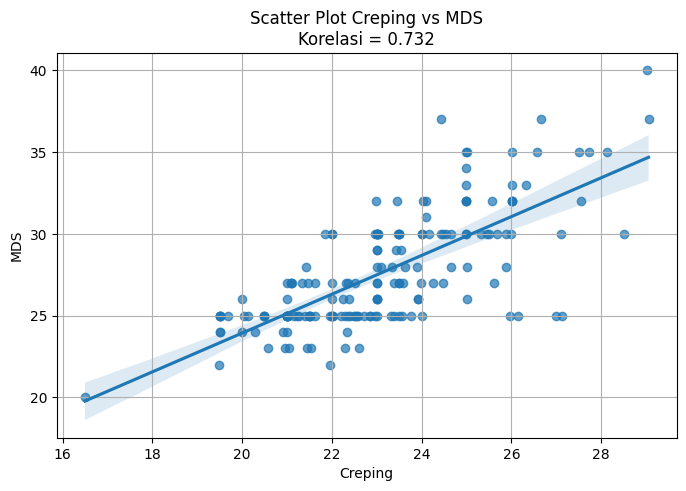

In [19]:
# Hitung korelasi Pearson
corr = df['Mean_Creping'].corr(df['MDS'])

# Plot
plt.figure(figsize=(8,5))

sns.regplot(
    x=df['Mean_Creping'],
    y=df['MDS'],
    scatter_kws={'alpha':0.7}
)

plt.title(f'Scatter Plot Creping vs MDS\nKorelasi = {corr:.3f}')
plt.xlabel('Creping')
plt.ylabel('MDS')

plt.grid(True)
plt.show()

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Start_Time               175 non-null    datetime64[us]
 1   End_Time                 175 non-null    datetime64[us]
 2   Data_Count               175 non-null    int64         
 3   Mean_Creping             175 non-null    float64       
 4   Mean_Yankee Speed        175 non-null    float64       
 5   Mean_Pope Reel Speed     175 non-null    float64       
 6   Mean_Yankee Pressure     175 non-null    float64       
 7   Mean_Stock Flow          175 non-null    float64       
 8   Mean_Stock Consistency   175 non-null    float64       
 9   Mean_Flow Coating        175 non-null    float64       
 10  Mean_Flow Release        175 non-null    float64       
 11  Mean_Jet Wire Ratio      175 non-null    float64       
 12  Mean_Load KWH Refiner    175 non-null    float6

## Modelling Linear Regression

In [21]:
# Create Pseudo_Mass Feature
df['pseudo_mass'] = (df['Mean_Stock Flow'] * df['Mean_Stock Consistency'])/ df['Mean_Yankee Speed']

# Create Coating-Release Ratio Feature
df['coating_release_ratio'] = df['Mean_Flow Coating'] / df['Mean_Flow Release']

# X Variables
features = [
    'Mean_Yankee Pressure',
    'Mean_Creping',
    '% NBKP',
    'Mean_Load KWH Refiner',
    'Mean_Jet Wire Ratio',
    'GSM',
    'coating_release_ratio',
    'pseudo_mass'
]

In [22]:
# X Variables
X = df[features]

# Y Variables
target = 'MDS'
y = df[target]

In [23]:
# BACKWARD ELIMINATION
selected_features = features.copy()

while True:
    X_model = sm.add_constant(df[selected_features])
    model = sm.OLS(y, X_model).fit()
    p_values = model.pvalues.drop('const')
    max_p = p_values.max()
    if max_p > 0.05:
        remove_feature = p_values.idxmax()
        print(f"Menghapus: {remove_feature} (p-value = {max_p:.4f})")
        selected_features.remove(remove_feature)
    else:
        break

# MODEL FINAL

print("\n===== FEATURE TERPILIH =====")
print(selected_features)

print("\n===== SUMMARY MODEL FINAL =====")
print(model.summary())

Menghapus: % NBKP (p-value = 0.9525)
Menghapus: Mean_Jet Wire Ratio (p-value = 0.6020)
Menghapus: GSM (p-value = 0.3011)
Menghapus: coating_release_ratio (p-value = 0.4569)
Menghapus: Mean_Load KWH Refiner (p-value = 0.2236)
Menghapus: Mean_Yankee Pressure (p-value = 0.3554)
Menghapus: pseudo_mass (p-value = 0.1487)

===== FEATURE TERPILIH =====
['Mean_Creping']

===== SUMMARY MODEL FINAL =====
                            OLS Regression Results                            
Dep. Variable:                    MDS   R-squared:                       0.535
Model:                            OLS   Adj. R-squared:                  0.532
Method:                 Least Squares   F-statistic:                     199.2
Date:                Fri, 29 May 2026   Prob (F-statistic):           1.37e-30
Time:                        15:38:58   Log-Likelihood:                -399.63
No. Observations:                 175   AIC:                             803.3
Df Residuals:                     173   BIC:     

### Import Model

In [24]:
import joblib
import os

# Folder model
#os.makedirs("models/PM14/MDS", exist_ok=True)

# Simpan model
#joblib.dump(model_no_const, "models/PM14/MDS/model.pkl")

# Simpan fitur
#joblib.dump(features, "models/PM14/MDS/features.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!


## Pemeriksaan Asumsi IIDN

### Independen (Autokorelasi)

In [25]:
DW = sm.stats.durbin_watson(model.resid)
print('Nilai DW =', DW)
if DW > 1.5 and DW < 2.5:
    print('Tidak ada autokorelasi (baik positif maupun negatif)')
elif DW < 1.5:
    print('Terdapat autokorelasi positif.')
elif DW > 2.5:
    print('Terdapat autokorelasi negatif.')

Nilai DW = 1.1520645360872133
Terdapat autokorelasi positif.


### Indentik (Heterokesdastisitas)

In [26]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Breusch-Pagan Test
# H0: Homoskedastisitas (Varians konstan)
bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(25.246778570908383), 'LM-Test p-value': np.float64(5.044375279344931e-07), 'F-Statistic': np.float64(29.165934803180583), 'F-Test p-value': np.float64(2.1691982745751168e-07)}


Terjadi Heteroskedastisitas yang parah pada model. Varians dari residual terbukti secara empiris tidak konstan.

### Normalitas

In [27]:
# Libraries
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

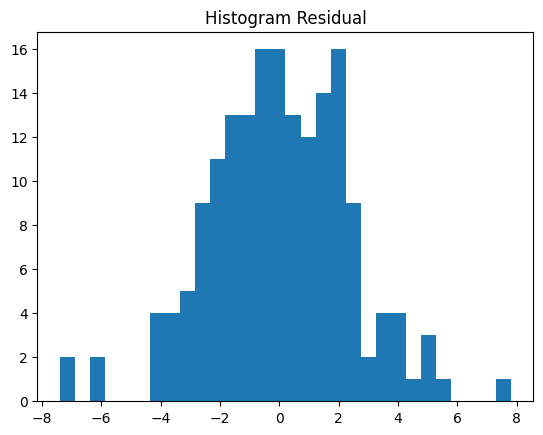

In [28]:
# Histogram
plt.figure()
plt.hist(model.resid, bins=30)
plt.title("Histogram Residual")
plt.show()

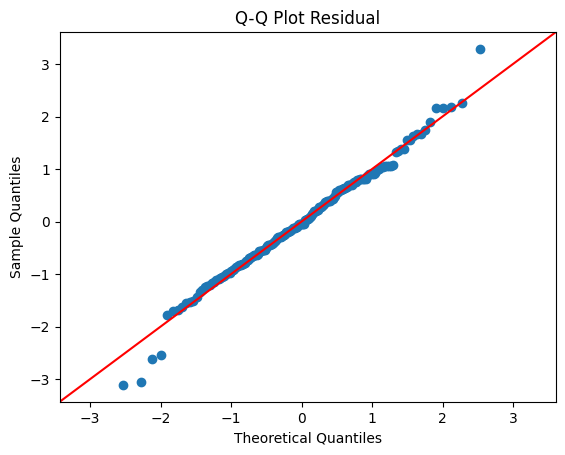

In [29]:
# Visualisasi (Q-Q Plot)
sm.qqplot(model.resid, line='45', fit=True)
plt.title("Q-Q Plot Residual")
plt.show()

In [30]:
# Uji Statistik (Shapiro-Wilk)
# H0: Data berdistribusi normal
# H1: Data tidak berdistribusi normal

stat, p_value = stats.shapiro(model.resid)

# Jika p-value < 0.05, residual tidak berdistribusi normal
print(f"Shapiro-Wilk Test: p-value = {p_value}")
if p_value < 0.05:
    print('residual tidak berdistribusi normal')
else:
    print('residual berdistribusi normal.')

Shapiro-Wilk Test: p-value = 0.23847559455256828
residual berdistribusi normal.


### Multikolinearitas

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Menghitung VIF untuk setiap variabel independen
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

                 Feature           VIF
0   Mean_Yankee Pressure   1239.302212
1           Mean_Creping    309.267112
2                 % NBKP    568.872640
3  Mean_Load KWH Refiner    253.999977
4    Mean_Jet Wire Ratio  64587.310151
5                    GSM  62322.441640
6  coating_release_ratio    108.375400
7            pseudo_mass   6162.390381
